# Forberedelsen af data

In [1]:
#Libriaries & Models
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

from IPython.display import clear_output
from skimage.io import imread
from skimage.transform import resize

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

from scipy.spatial.distance import cdist
from scipy.linalg import pinv
from sklearn.metrics import mean_squared_error

import os
import pickle

import importlib
import src
importlib.reload(src)


Python random seed set.
NumPy random seed set.
Python random seed set.
NumPy random seed set.


<module 'src' from '/Users/hugojohnson/Desktop/Deep Learning/02456-deep-learning-project/src/__init__.py'>

Access the datasets

In [2]:
input_features = ['beta1', 'beta2', 'beta3', 'Theta', 'omega_r', 'Vwx']
output_features = ['Mz1', 'Mz2', 'Mz3']
filtered_df = src.dataset.load_filtered_data(input_features, output_features)

Loaded from pickle


Vælger de features der krav på at bruge til modellen og forbereder dataen.

In [3]:
X, y, _, _ = src.dataset.load_normalized_data()
combined_df_scaled = pd.DataFrame(np.hstack((X, y)), columns=filtered_df.columns)


Loaded from pickle


In [4]:
import pandas as pd

def create_time_delayed_features_optimized(df, input_features, time_steps=3):
    """
    Create time-delayed features for a given DataFrame using vectorized operations.
    
    Args:
    - df: The DataFrame containing the scaled data.
    - input_features: The list of input feature names.
    - time_steps: The number of previous time steps to include (default is 3).
    
    Returns:
    - A DataFrame with time-delayed features.
    """
    delayed_df = pd.DataFrame(index=df.index)

    # For each feature, create shifted columns for each time delay and add to the DataFrame
    for feature in input_features:
        for t in range(time_steps + 1):
            delayed_df[f"{feature}_t-{t}"] = df[feature].shift(t)

    # Drop rows with NaN values (from initial time steps with no delay data)
    delayed_df.dropna(inplace=True)
    return delayed_df

# Create time-delayed features for the input features (using 3 previous time steps)
delayed_input_df = create_time_delayed_features_optimized(combined_df_scaled, input_features, time_steps=3)

# Merge the time-delayed input features with the original output features (Mz1, Mz2, Mz3)
final_df = pd.concat([delayed_input_df.reset_index(drop=True), combined_df_scaled[output_features].iloc[3:].reset_index(drop=True)], axis=1)

#rename the keys for input and output
all_features = final_df.columns
print(all_features)

#overwrite input features to match the added time delayed features
input_features = ['beta1_t-0', 'beta1_t-1', 'beta1_t-2', 'beta1_t-3', 'beta2_t-0',
       'beta2_t-1', 'beta2_t-2', 'beta2_t-3', 'beta3_t-0', 'beta3_t-1',
       'beta3_t-2', 'beta3_t-3', 'Theta_t-0', 'Theta_t-1', 'Theta_t-2',
       'Theta_t-3', 'omega_r_t-0', 'omega_r_t-1', 'omega_r_t-2', 'omega_r_t-3',
       'Vwx_t-0', 'Vwx_t-1', 'Vwx_t-2', 'Vwx_t-3']
# View the final DataFrame with time-delayed features
print(final_df.head())


Index(['beta1_t-0', 'beta1_t-1', 'beta1_t-2', 'beta1_t-3', 'beta2_t-0',
       'beta2_t-1', 'beta2_t-2', 'beta2_t-3', 'beta3_t-0', 'beta3_t-1',
       'beta3_t-2', 'beta3_t-3', 'Theta_t-0', 'Theta_t-1', 'Theta_t-2',
       'Theta_t-3', 'omega_r_t-0', 'omega_r_t-1', 'omega_r_t-2', 'omega_r_t-3',
       'Vwx_t-0', 'Vwx_t-1', 'Vwx_t-2', 'Vwx_t-3', 'Mz1', 'Mz2', 'Mz3'],
      dtype='object')
   beta1_t-0  beta1_t-1  beta1_t-2  beta1_t-3  beta2_t-0  beta2_t-1  \
0   0.684047   0.685333   0.684014   0.684184   0.682495   0.683675   
1   0.685297   0.684047   0.685333   0.684014   0.683864   0.682495   
2   0.684235   0.685297   0.684047   0.685333   0.682929   0.683864   
3   0.684775   0.684235   0.685297   0.684047   0.683602   0.682929   
4   0.687129   0.684775   0.684235   0.685297   0.686091   0.683602   

   beta2_t-2  beta2_t-3  beta3_t-0  beta3_t-1  ...  omega_r_t-1  omega_r_t-2  \
0   0.682267   0.682380   0.684942   0.686134  ...     0.653796     0.653848   
1   0.683675   0.68226

In [5]:
print(final_df[input_features].head())

   beta1_t-0  beta1_t-1  beta1_t-2  beta1_t-3  beta2_t-0  beta2_t-1  \
0   0.684047   0.685333   0.684014   0.684184   0.682495   0.683675   
1   0.685297   0.684047   0.685333   0.684014   0.683864   0.682495   
2   0.684235   0.685297   0.684047   0.685333   0.682929   0.683864   
3   0.684775   0.684235   0.685297   0.684047   0.683602   0.682929   
4   0.687129   0.684775   0.684235   0.685297   0.686091   0.683602   

   beta2_t-2  beta2_t-3  beta3_t-0  beta3_t-1  ...  Theta_t-2  Theta_t-3  \
0   0.682267   0.682380   0.684942   0.686134  ...   0.375563   0.369998   
1   0.683675   0.682267   0.686302   0.684942  ...   0.373894   0.375563   
2   0.682495   0.683675   0.685357   0.686302  ...   0.377984   0.373894   
3   0.683864   0.682495   0.686022   0.685357  ...   0.380595   0.377984   
4   0.682929   0.683864   0.688503   0.686022  ...   0.378951   0.380595   

   omega_r_t-0  omega_r_t-1  omega_r_t-2  omega_r_t-3   Vwx_t-0   Vwx_t-1  \
0     0.652304     0.653796     0.65384

# Oprettelsen af modellen

Vælger de variabler som skal bruge til at predicte output variablerne
og sætter mængden af dataen som skal trænes, og mængden som skal testes

her fra har vi sat test størrelsen på 0.20 %

# RBF - Implementation

In [6]:
class RBFNetwork:
    def __init__(self, centers, sigma=1.0):
        self.centers = centers  # Centrene for RBF-enhederne (det skjulte lag)
        self.sigma = sigma      # Spredningsparameter for Gaussian-funktionen
        self.weights = None     # Vægte til outputlaget

    def _rbf(self, X):
        # Calculates radial basis functions (Gaussian) for input X
        distances = cdist(X, self.centers, 'euclidean')  # Distance from input to each center
        return np.exp(-distances ** 2 / (2 * self.sigma ** 2))  # Gaussian RBF

    def fit(self, X, y):
        # Train the model (calculate weights based on target variable y)
        G = self._rbf(X)  # Calculate activations in the hidden layer
        self.weights = pinv(G).dot(y)  # Calculate weights for the output layer (using pseudo-inverse)


    def predict(self, X):
        # Forudsig output for nye data
        G = self._rbf(X)
        return G.dot(self.weights)


In [7]:
# set test and train and centers for the model 
X = final_df[input_features]   # Input variables
y = final_df[output_features]  # Output variables

# Split dataene i træning og test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Antag at X_train er en NumPy-array (hvis det er en DataFrame, konverter den med .values)
X_train = X_train.values if hasattr(X_train, 'values') else X_train
y_train = y_train.values if hasattr(y_train, 'values') else y_train

#calculating the cluster centers for different numbers of clusters

centers_list = [] #maybe it is better to use a dictionary and have the no. of centers as a key?
num_centers_list = [1,10, 20, 50] #,100, 150] # Set the number of RBF centers (same as the number of clusters)

pickle_path = os.path.join('data', 'interim', f'centers01_{"-".join(str(x) for x in num_centers_list)}.pkl')
print(pickle_path)
if os.path.exists(pickle_path):
    # Load the dictionary from the file
    with open(pickle_path, "rb") as f:
        centers_list = pickle.load(f)
    print("Loaded from pickle")
else:
    for num_center in num_centers_list:
        print(num_center)
        # Apply K-Means to X_train to find cluster centers
        kmeans = KMeans(n_clusters=num_center, n_init=10, random_state=0)
        kmeans.fit(X_train)
        
        # The cluster centers will serve as the RBF centers
        centers = kmeans.cluster_centers_
        centers_list.append(centers)
    with open(pickle_path, "wb") as f:
        pickle.dump(centers_list, f)
    print("Generated and saved to pickle")




data/interim/centers01_1-10-20-50.pkl
1
10
20
50
Generated and saved to pickle


In [8]:
print(centers_list[0])


[[0.40177689 0.40177621 0.40177708 0.40177695 0.40205571 0.40205499
  0.40205581 0.40205561 0.40263715 0.40263647 0.40263733 0.40263719
  0.49974046 0.499736   0.49973021 0.49971998 0.59984888 0.59984698
  0.59984935 0.59984962 0.44664588 0.44664372 0.4466409  0.44664054]]


# Tuning of parameters - sigma and no. of centers

Mean Squared Error of train data: 0.04277495121543192 Mean Squared Error testdata: 0.042822406178044746
Mean Squared Error of train data: 0.008176532465774064 Mean Squared Error testdata: 0.008171210863826639
Mean Squared Error of train data: 0.004280253775091331 Mean Squared Error testdata: 0.0042788576143680925
Mean Squared Error of train data: 0.0033639661714967447 Mean Squared Error testdata: 0.0033736756472188298
[0.04277495121543192, 0.008176532465774064, 0.004280253775091331, 0.0033639661714967447] [0.042822406178044746, 0.008171210863826639, 0.0042788576143680925, 0.0033736756472188298]


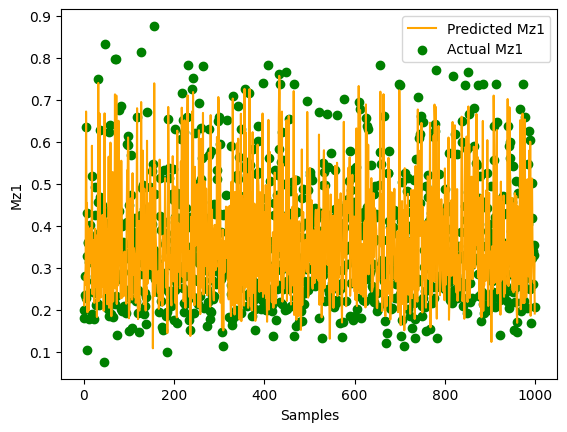

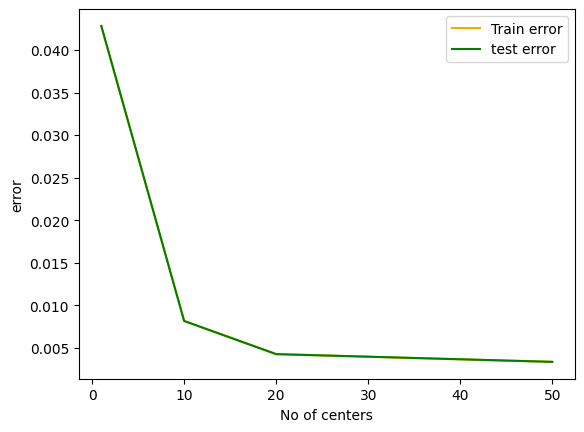

In [9]:
#tuning no. of centers and printing results
mse_train_list = []
mse_test_list = []
sigma = 1
for index in range(len(centers_list)):
    rbf_net = RBFNetwork(centers_list[index], sigma)
    rbf_net.fit(X_train, y_train)

    y_train_pred = rbf_net.predict(X_train)
    y_pred = rbf_net.predict(X_test)
        
    # calculate MSE
    mse_train = mean_squared_error(y_train,y_train_pred)
    mse_test = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error of train data:",  mse_train, "Mean Squared Error testdata:", mse_test)
    mse_train_list.append(mse_train)
    mse_test_list.append(mse_test)

print(mse_train_list, mse_test_list)

#plotting the errors
plt.plot(range(1000), y_pred[:1000, 0], label='Predicted Mz1', color = 'orange')
plt.scatter(range(1000),y_test.iloc[:1000, 0], label='Actual Mz1', color='green')
plt.xlabel('Samples')
plt.ylabel('Mz1')
plt.legend()
plt.show()


#plotting the model prediction
plt.plot(num_centers_list, mse_train_list, label='Train error', color = 'orange')
plt.plot(num_centers_list,mse_test_list, label='test error', color='green')
plt.xlabel('No of centers')
plt.ylabel('error')
plt.legend()
plt.show()


sigma:0.4 Mean Squared Error of train data: 0.006729658185996652 Mean Squared Error testdata: 0.006715415040361374
sigma:0.8 Mean Squared Error of train data: 0.0034997211794624643 Mean Squared Error testdata: 0.0035059883929060825
sigma:1.0 Mean Squared Error of train data: 0.0033639661714967447 Mean Squared Error testdata: 0.0033736756472188298
sigma:1.2 Mean Squared Error of train data: 0.003390491982326809 Mean Squared Error testdata: 0.0034023254118481735
sigma:1.4 Mean Squared Error of train data: 0.003553144372321859 Mean Squared Error testdata: 0.0035598198874801923
sigma:2.0 Mean Squared Error of train data: 0.0037129898983643017 Mean Squared Error testdata: 0.00370805945275165
[0.006729658185996652, 0.0034997211794624643, 0.0033639661714967447, 0.003390491982326809, 0.003553144372321859, 0.0037129898983643017] [0.006715415040361374, 0.0035059883929060825, 0.0033736756472188298, 0.0034023254118481735, 0.0035598198874801923, 0.00370805945275165]


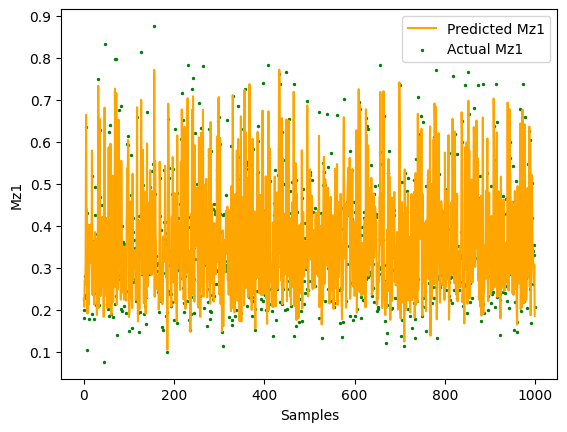

In [10]:
#tuning sigma and printing the results for time delayed model
sigma_list = [0.4, 0.8, 1.0, 1.2, 1.4, 2.0]
center_index = -1 # Use this to choose the number of centers, or leave it as -1 for the max. centers trained.
mse_train_list = []
mse_test_list = []
for sigma in sigma_list:
    rbf_net = RBFNetwork(centers_list[center_index], sigma)
    rbf_net.fit(X_train, y_train)

    y_train_pred = rbf_net.predict(X_train)
    y_pred = rbf_net.predict(X_test)
        
    # calculate MSE
    mse_train = mean_squared_error(y_train,y_train_pred)
    mse_test = mean_squared_error(y_test, y_pred)
    print(f'sigma:{sigma}',"Mean Squared Error of train data:",  mse_train, "Mean Squared Error testdata:", mse_test)
    mse_train_list.append(mse_train)
    mse_test_list.append(mse_test)

print(mse_train_list, mse_test_list)
plt.plot(range(1000), y_pred[:1000, 0], label='Predicted Mz1', color = 'orange')
plt.scatter(range(1000),y_test.iloc[:1000, 0], label='Actual Mz1', color='green', s=2)
plt.xlabel('Samples')
plt.ylabel('Mz1')
plt.legend()
plt.show()


#comparing test and train accuarcies

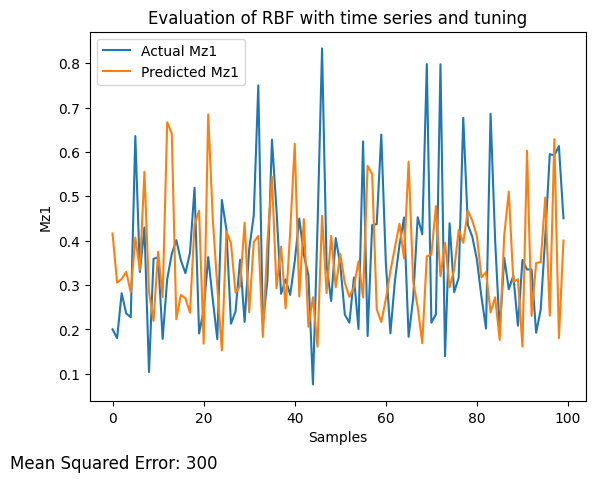

[0.199923   0.17989448 0.28122372 0.2357607  0.22728243 0.63558743
 0.32919365 0.4295323  0.10358752 0.35906536 0.36234075 0.17833543
 0.31298187 0.36986873 0.40085778 0.35556966 0.3265383  0.37251698
 0.51910844 0.19054883 0.24196266 0.36275603 0.26743722 0.17787719
 0.4917696  0.42526218 0.21252454 0.2402116  0.35670413 0.21655347
 0.38076941 0.45654124 0.74992732 0.21148935 0.30938805 0.62761755
 0.46796071 0.27993018 0.31263394 0.27749862 0.3530166  0.44968179
 0.36780745 0.32191389 0.07576566 0.43005063 0.83328161 0.34430679
 0.26366824 0.40549679 0.34583523 0.23316116 0.21485632 0.31693607
 0.20064928 0.62360588 0.18480149 0.43477361 0.43711877 0.63893942
 0.35013398 0.1907394  0.30999043 0.39021649 0.45197676 0.18302233
 0.26882437 0.45253701 0.41407234 0.79781674 0.21486257 0.23391097
 0.79745837 0.1393614  0.43905647 0.28350917 0.31626274 0.67692363
 0.43601134 0.40817047 0.35721129 0.27257594 0.20164202 0.68572728
 0.40043379 0.19670183 0.3611101  0.29038902 0.32085625 0.2082

In [ ]:
# plt.plot(range(1000), y_pred[:1000, 0], label='Predicted Mz1', color = 'orange')
# plt.scatter(range(1000),y_test.iloc[:1000, 0], label='Actual Mz1', color='green', s=2)

timeframe = 100
src.plots.evaluate_predictions(y_pred[:, 1][:timeframe], y_test.iloc[:timeframe, 0].to_numpy(), mse_test_list, name="RBF with time series and tuning")

print(y_test.iloc[:1000, 0].to_numpy())

# Old model for comparison 

In [11]:
#old model without time delay for comparison 


# set test and train and centers for the model 
X = combined_df_scaled[input_features]   # Input variables
y = combined_df_scaled[output_features]  # Output variables

# Split dataene i træning og test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Antag at X_train er en NumPy-array (hvis det er en DataFrame, konverter den med .values)
X_train = X_train.values if hasattr(X_train, 'values') else X_train
y_train = y_train.values if hasattr(y_train, 'values') else y_train


num_centers = 1  # Set the number of RBF centers (same as the number of clusters)
# Apply K-Means to X_train to find cluster centers
kmeans = KMeans(n_clusters=num_centers, n_init=10, random_state=0)
kmeans.fit(X_train)



KeyError: "None of [Index(['beta1_t-0', 'beta1_t-1', 'beta1_t-2', 'beta1_t-3', 'beta2_t-0',\n       'beta2_t-1', 'beta2_t-2', 'beta2_t-3', 'beta3_t-0', 'beta3_t-1',\n       'beta3_t-2', 'beta3_t-3', 'Theta_t-0', 'Theta_t-1', 'Theta_t-2',\n       'Theta_t-3', 'omega_r_t-0', 'omega_r_t-1', 'omega_r_t-2', 'omega_r_t-3',\n       'Vwx_t-0', 'Vwx_t-1', 'Vwx_t-2', 'Vwx_t-3'],\n      dtype='object')] are in the [columns]"

Mean Squared Error på testdata: 0.014263963195322601


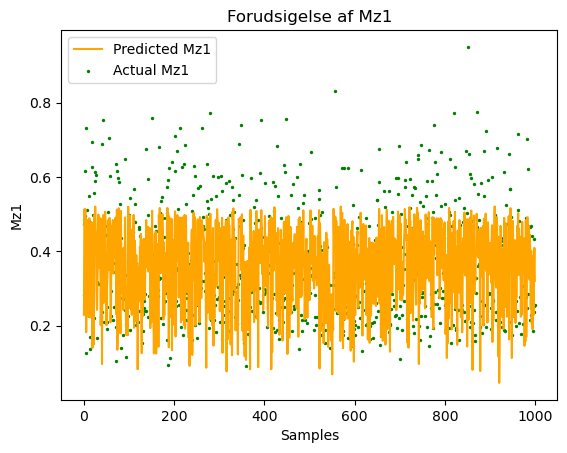

In [ ]:
#results of the model without time delay for comparison


rbf_net = RBFNetwork(centers, sigma=1.0)
rbf_net.fit(X_train, y_train)

y_pred = rbf_net.predict(X_test)


# Beregn MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error på testdata:", mse)


plt.plot(range(1000), y_pred[:1000, 0], label='Predicted Mz1', color = 'orange')
plt.scatter(range(1000),y_test.iloc[:1000, 0], label='Actual Mz1', color='green', s=2)
plt.xlabel('Samples')
plt.ylabel('Mz1')
plt.legend()
plt.show()